# 03 — Worst-of FCN Pricing on AMZN / META / MU (Oct 2025 → May 2026)

This notebook prices a **6-month, monthly-observed worst-of FCN** on AMZN, META, MU
issued at **17 Oct 2025**, then replays the *actual* payoff on the realised price
path through maturity at **4 May 2026** to compare model vs. reality.

**Product spec (JT-supplied)**

| Field | Value |
|---|---|
| Underlyings | AMZN, META, MU |
| Notional | USD 50,000 |
| Issue date | 31 Oct 2025 |
| Initial valuation | 17 Oct 2025 |
| Final valuation | 30 Apr 2026 |
| Maturity | 4 May 2026 |
| Coupon | 1.535% per period, **flat** (18.42% p.a., monthly) |
| Autocall barrier | 100% of initial, worst-of basis |
| Strike (= KI) | 70% of initial, **geared** downside (physical settlement at strike) |
| KI observation | European (at final valuation only) |
| Autocall fixings | 1 Dec '25, 31 Dec '25, 2 Feb '26, 2 Mar '26, 31 Mar '26 |
| Payment dates | 3 Dec '25, 5 Jan '26, 4 Feb '26, 4 Mar '26, 2 Apr '26, 4 May '26 |

**What "use historical prices" means here**: market inputs are taken **as-of 17 Oct 2025**
(no look-ahead — realised vol/corr from a 5Y window ending 17 Oct 2025, Treasury yields
from that date, spots = 17 Oct 2025 close). The note has already matured, so once we
have a model price we also pull the actual prices through 4 May 2026 and replay the
realised cashflow schedule.


In [1]:
import sys, os
# Ensure the repo root is on sys.path regardless of where Jupyter was launched.
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.market_data import load_market_data, _download_history
from src.fcn_payoff import FCNProduct, ObservationGrid, probability_decomposition
from src.mc_pricer import price_fcn, realised_payoff

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.set_printoptions(suppress=True, precision=4)


## 1. Market data as-of 17 Oct 2025

We restrict yfinance to a 5Y window ending 17 Oct 2025, compute realised vol/corr on
that window, take the close on 17 Oct 2025 as $S_0$, and pull the Treasury curve on
that date interpolated to the 0.5Y tenor (matching the note's tenor).

In [2]:
ISSUE_DATE = date(2025, 10, 17)
TICKERS = ("AMZN", "META", "MU")

market = load_market_data(
    tickers=TICKERS,
    lookback_years=5,
    target_T=0.5,            # 6M Treasury for a 6M note
    as_of=ISSUE_DATE,
)
print(market.summary())


MarketData snapshot as of 2026-05-21T02:21:57.109379+00:00
Tickers      : ['AMZN', 'META', 'MU']
Spots        : {'AMZN': np.float64(213.04), 'META': np.float64(715.723), 'MU': np.float64(202.2133)}
Vols (ann.)  : {'AMZN': np.float64(0.3502), 'META': np.float64(0.4397), 'MU': np.float64(0.4713)}
Div yields   : {'AMZN': np.float64(0.0), 'META': np.float64(0.0029), 'MU': np.float64(0.00227)}
Risk-free 1Y : 0.03819
Correlation matrix:
       AMZN   META     MU
AMZN 1.0000 0.6139 0.4422
META 0.6139 1.0000 0.4176
MU   0.4422 0.4176 1.0000
Sources:
  as_of: 2025-10-17
  spots: yfinance daily closes (last bar on or before 2025-10-17)
  history: yfinance 5Y daily closes ending 2025-10-17
  realised_vols: log-return std × √252
  implied_vols: AMZN: realised 5Y vol (0.3502) @ 2025-10-17; META: realised 5Y vol (0.4397) @ 2025-10-17; MU: realised 5Y vol (0.4713) @ 2025-10-17
  dividends: AMZN: hardcoded fallback (0.0000); META: trailing 12M dividends / spot @ 2025-10-17 (0.0029); MU: trailing 12M d

## 2. Product spec — the JT-supplied parameters

`FCNProduct` validates the date schedule and the barrier ordering, and exposes
year fractions used by the simulation grid.

In [3]:
product = FCNProduct(
    notional=50_000.0,
    coupon_rate=0.01535,
    obs_dates=(
        date(2025, 12, 1),
        date(2025, 12, 31),
        date(2026, 2, 2),
        date(2026, 3, 2),
        date(2026, 3, 31),
        date(2026, 4, 30),  # final valuation
    ),
    pay_dates=(
        date(2025, 12, 3),
        date(2026, 1, 5),
        date(2026, 2, 4),
        date(2026, 3, 4),
        date(2026, 4, 2),
        date(2026, 5, 4),   # maturity
    ),
    issue_date=ISSUE_DATE,
    autocall_barrier=1.00,
    strike=0.70,
    n_autocall_obs=5,
    coupon_barrier=None,        # flat coupons, no barrier
    geared_downside=True,       # physical settlement at strike: redemption = N * W(T) / strike when knocked in
    continuous_ki=False,        # KI checked at final valuation only
)

print('Obs year fractions :', np.round(product.obs_year_fractions(), 4))
print('Pay year fractions :', np.round(product.pay_year_fractions(), 4))
print('Sim grid (daily)   :', ObservationGrid.from_product(product).obs_indices)


Obs year fractions : [0.1233 0.2055 0.2959 0.3726 0.4521 0.5342]
Pay year fractions : [0.1288 0.2192 0.3014 0.3781 0.4575 0.5452]
Sim grid (daily)   : [ 45  75 108 136 165 195]


## 3. Monte Carlo price

Daily simulation grid (199 steps = calendar days from 17 Oct 2025 to 4 May 2026),
antithetic variates on, 50,000 primal paths = 100,000 total.

In [4]:
result = price_fcn(
    market=market,
    product=product,
    n_paths=50_000,
    antithetic=True,
    seed=20260511,
)
print(result.summary())


FCN price : 50,317.3759  (= 100.6348% of notional)
MC SE     : 13.7717  (0.027% of price)
Paths     : 100,000

Probability decomposition:
  P(first autocall = period 1) = 0.2314
  P(first autocall = period 2) = 0.0870
  P(first autocall = period 3) = 0.0549
  P(first autocall = period 4) = 0.0355
  P(first autocall = period 5) = 0.0270
  P(autocall total)             = 0.4359
  P(KI at maturity, no AC)      = 0.2627
  P(alive, no KI, no AC)        = 0.3013

Diagnostics:
  tickers: ['AMZN', 'META', 'MU']
  as_of: 2025-10-17
  rate: 0.03819 (yfinance interpolated ^IRX/^FVX -> 0.50Y (as_of 2025-10-17))
  vols: {'AMZN': 0.3502, 'META': 0.4397, 'MU': 0.4713}
  divs: {'AMZN': 0.0, 'META': 0.0029, 'MU': 0.00227}
  spots: {'AMZN': 213.04, 'META': 715.723, 'MU': 202.2133}
  sim_n_steps: 199
  sim_T_years: 0.545205
  antithetic: True
  n_paths_drawn: 50000
  seed: 20260511


### Interpretation

For an FCN to be issued at par (100% of notional), the model price should be **at or
above par** — anything below means the structurer is underpaying for the embedded
short worst-of put / long autocall. Read the % of notional and the probability
breakdown together: a high P(autocall in period 1) implies the issuer expects
the note to die fast at par + one coupon, so the model price hugs par from above.

## 4. Distribution of present values

Per-path discounted PVs from the MC. The vertical line is the MC mean.

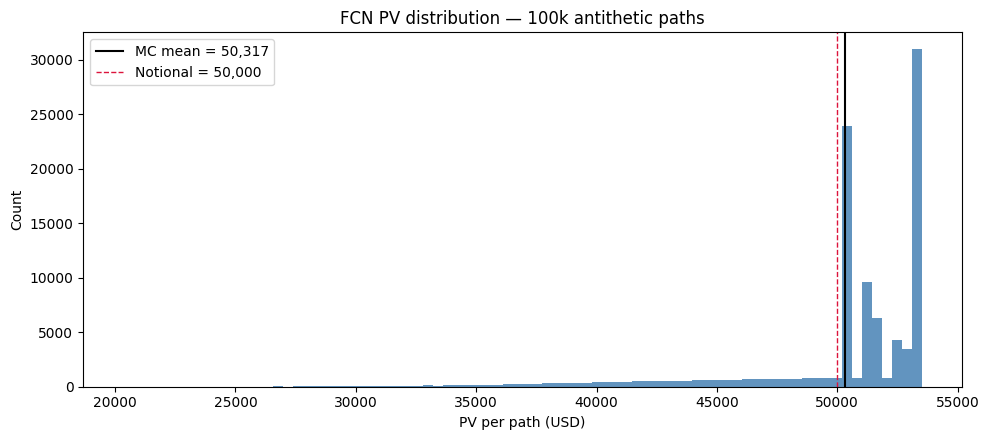

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(result.pv_samples, bins=80, color='steelblue', alpha=0.85)
ax.axvline(result.price, color='black', lw=1.5, label=f'MC mean = {result.price:,.0f}')
ax.axvline(product.notional, color='crimson', lw=1.0, ls='--', label=f'Notional = {product.notional:,.0f}')
ax.set_xlabel('PV per path (USD)')
ax.set_ylabel('Count')
ax.set_title('FCN PV distribution — 100k antithetic paths')
ax.legend()
fig.tight_layout(); plt.show()


## 5. Worst-of trajectory chart vs barriers

Twenty randomly-chosen paths of the worst-of normalised price, against the
autocall (100%) and strike (70%) lines and the six observation dates.

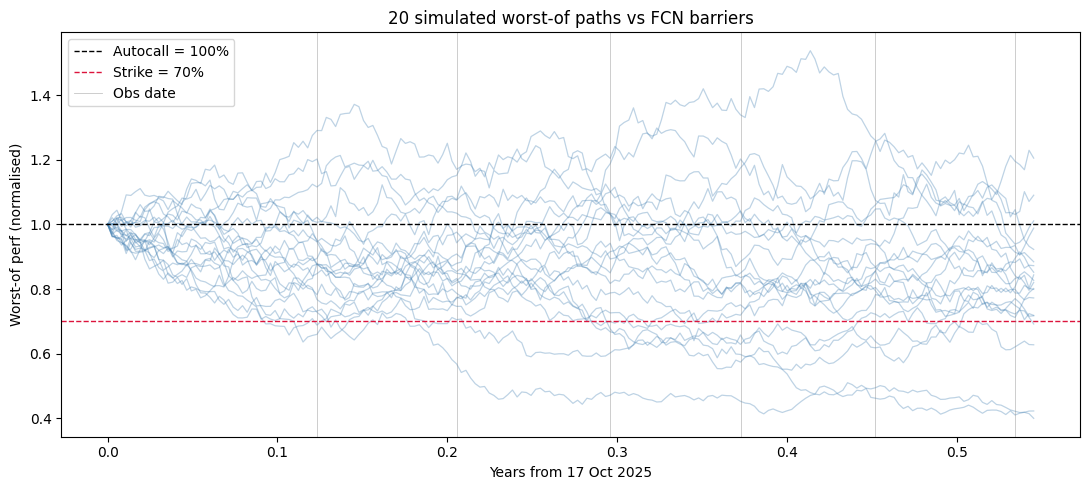

In [6]:
from src.gbm_simulation import SimulationConfig, simulate_paths

grid = ObservationGrid.from_product(product)
cfg = SimulationConfig(
    spots=market.spots, vols=market.vols, divs=market.divs, rate=market.rate, corr=market.corr,
    T=grid.sim_T, n_steps=grid.sim_n_steps, n_paths=500, antithetic=False, seed=42,
)
paths = simulate_paths(cfg)
worst = (paths / market.spots).min(axis=2)  # (n_paths, n_steps+1)

t_grid = np.linspace(0, grid.sim_T, grid.sim_n_steps + 1)
obs_yf = product.obs_year_fractions()

fig, ax = plt.subplots(figsize=(11, 5))
sample = np.random.default_rng(0).choice(paths.shape[0], size=20, replace=False)
for i in sample:
    ax.plot(t_grid, worst[i], color='steelblue', alpha=0.35, lw=0.9)
ax.axhline(product.autocall_barrier, color='black', lw=1.0, ls='--', label='Autocall = 100%')
ax.axhline(product.strike, color='crimson', lw=1.0, ls='--', label='Strike = 70%')
for j, t in enumerate(obs_yf):
    label = 'Obs date' if j == 0 else None
    ax.axvline(t, color='grey', alpha=0.45, lw=0.6, label=label)
ax.set_xlabel('Years from 17 Oct 2025')
ax.set_ylabel('Worst-of perf (normalised)')
ax.set_title('20 simulated worst-of paths vs FCN barriers')
ax.legend(loc='upper left')
fig.tight_layout(); plt.show()


## 6. Ex-post replay — what actually happened?

The note matured on 4 May 2026 (before today). We now pull the *actual* AMZN /
META / MU closes over the life of the note and run the deterministic payoff.

In [7]:
post_history = _download_history(
    TICKERS,
    lookback_years=1,                      # 1Y window comfortably covers Oct 25 -> May 26
    end=date(2026, 5, 5),
)
# Restrict to the life of the note for display.
life_mask = (post_history.index >= pd.Timestamp(ISSUE_DATE)) & (post_history.index <= pd.Timestamp(2026, 5, 4))
life = post_history.loc[life_mask, list(TICKERS)]
display(life.head())
display(life.tail())


,AMZN,META,MU
Date,,,
2025-10-17,213.0400,715.7230,202.2133
2025-10-20,216.4800,730.9475,206.5997
2025-10-21,222.0300,732.0457,202.1234
2025-10-22,217.9500,732.1854,198.3065
2025-10-23,221.0900,732.7745,206.5398


,AMZN,META,MU
Date,,,
2026-04-28,259.7000,671.3400,504.2900
2026-04-29,263.0400,669.1200,518.4600
2026-04-30,265.0600,611.9100,517.1600
2026-05-01,268.2600,608.7500,542.2100
2026-05-04,272.0500,610.4100,576.4500


In [8]:
realised = realised_payoff(history=post_history[list(TICKERS)], product=product, rate=market.rate)

print(f"Outcome             : {realised['outcome']}")
print(f"Total cash paid     : {realised['total_paid']:,.2f}")
print(f"PV at issue (model r): {realised['pv_at_issue']:,.2f}")
print()
print("Worst-of trajectory at each obs date:")
for d, w in realised['worst_path']:
    print(f"  {d}: {w:.4f}")
print()
print("Cashflow schedule:")
for pay_dt, label, amt in realised['cashflows']:
    print(f"  {pay_dt}: {label:<35s} {amt:>12,.2f}")


Outcome             : matured_par
Total cash paid     : 54,605.00
PV at issue (model r): 53,515.53

Worst-of trajectory at each obs date:
  2025-12-01: 0.8939
  2025-12-31: 0.9215
  2026-02-02: 0.9861
  2026-03-02: 0.9124
  2026-03-31: 0.7994
  2026-04-30: 0.8550

Cashflow schedule:
  2025-12-03: coupon_1                                  767.50
  2026-01-05: coupon_2                                  767.50
  2026-02-04: coupon_3                                  767.50
  2026-03-04: coupon_4                                  767.50
  2026-04-02: coupon_5                                  767.50
  2026-05-04: coupon_6_final                            767.50
  2026-05-04: maturity_redemption_par                50,000.00


## 7. Model price vs realised payoff

The model gives an *expected* PV across the risk-neutral distribution; the
realised replay gives a *single sample* from the real-world path. The two
should be loosely consistent — and we don't expect equality, because:

1. **Risk-neutral vs real-world drift.** GBM under $\mathbb{Q}$ uses $r-q$ as
   drift; the realised path used the actual physical drift, which for AMZN /
   META / MU over a 6M window in late 2025 / early 2026 may be very different.
2. **One realisation vs an expectation.** The realised PV is a single draw;
   the MC 1-sigma band gives the right scale of "how unlikely is this draw."

What we *do* expect to match exactly is the deterministic discounted-cashflow
calculus once a path is fixed — verified in `tests/test_mc_pricer.py`.

In [9]:
realised_pv = realised['pv_at_issue']
delta = realised_pv - result.price
pv = result.pv_samples
path_std = pv.std(ddof=1)
percentile = float((pv < realised_pv).mean()) * 100.0
print(f"Realised PV (at model r)       : {realised_pv:>12,.2f}")
print(f"Model MC price (mean)          : {result.price:>12,.2f}")
print(f"Δ (realised − model)           : {delta:>+12,.2f}")
print()
print(f"MC SE (precision of the mean)  : {result.standard_error:>12,.2f}")
print(f"Per-path PV stdev (dispersion) : {path_std:>12,.2f}")
print(f"Δ in per-path stdev units      : {delta / path_std:>+12,.3f} (≈ z-score in path distribution)")
print(f"Percentile of realised PV in MC: {percentile:>12.2f}%")


Realised PV (at model r)       :    53,515.53
Model MC price (mean)          :    50,317.38
Δ (realised − model)           :    +3,198.16

MC SE (precision of the mean)  :        13.77
Per-path PV stdev (dispersion) :     4,355.00
Δ in per-path stdev units      :       +0.734 (≈ z-score in path distribution)
Percentile of realised PV in MC:       100.00%


## 8. Realised worst-of trajectory overlay

Same axes as §5, but with the *actual* worst-of path superimposed in black
on the simulated cone.

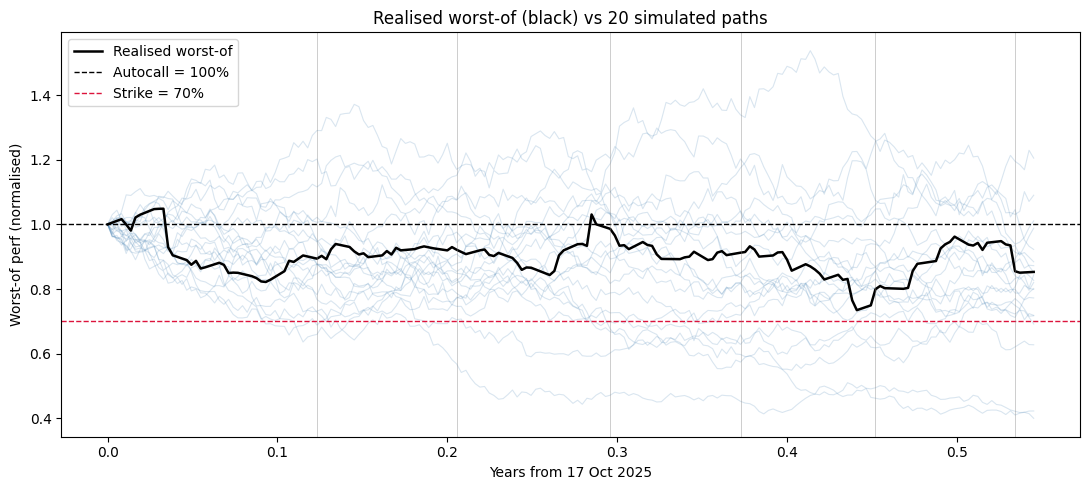

In [10]:
initial = life.iloc[0].to_numpy(dtype=float)
realised_perf = life.to_numpy(dtype=float) / initial
realised_worst = realised_perf.min(axis=1)
realised_t = (life.index - pd.Timestamp(ISSUE_DATE)).days / 365.0

fig, ax = plt.subplots(figsize=(11, 5))
for i in sample:
    ax.plot(t_grid, worst[i], color='steelblue', alpha=0.20, lw=0.8)
ax.plot(realised_t, realised_worst, color='black', lw=1.8, label='Realised worst-of')
ax.axhline(product.autocall_barrier, color='black', lw=1.0, ls='--', label='Autocall = 100%')
ax.axhline(product.strike, color='crimson', lw=1.0, ls='--', label='Strike = 70%')
for t in obs_yf:
    ax.axvline(t, color='grey', alpha=0.45, lw=0.6)
ax.set_xlabel('Years from 17 Oct 2025')
ax.set_ylabel('Worst-of perf (normalised)')
ax.set_title('Realised worst-of (black) vs 20 simulated paths')
ax.legend(loc='upper left')
fig.tight_layout(); plt.show()


## 9. Headline takeaways

- Model MC price, %-of-notional, MC SE in §3.
- P(autocall total), P(KI at maturity), P(par at maturity) in §3 → tells us the
  shape of the structurer's expected outcome distribution.
- Realised outcome vs model expectation in §7 → the path-specific result vs
  the risk-neutral mean.

**Phase 3 deliverable complete.** Next phases:
- Phase 4: 1D Crank–Nicolson PDE to cross-validate MC on the single-asset
  reduction.
- Phase 5: Greeks (Δ, Γ, vega, ρ_pair) by bump-and-revalue with CRN.
- Phase 6: worst-of put control variate to compress MC SE further.
- Phase 7: write-up.